## **computer vision - lab 2 - task 2**
### **multi-modal cardiac image fusion (CT + MRI)**
#### **23K-0074**

#### **setup**

In [11]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

os.makedirs("output", exist_ok=True)


def load_gray(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"could not read '{path}' - put the sample file in the data/ folder (see README.md)")
    return img


def log_transform(img):
    # s = c * log(1 + r), with c chosen so the brightest input maps to 255
    f = img.astype(np.float64)
    c = 255.0 / np.log1p(max(f.max(), 1.0))
    return np.clip(c * np.log1p(f), 0, 255).astype(np.uint8)


def gamma_transform(img, gamma):
    # s = 255 * (r / 255) ^ gamma  (gamma < 1 brightens, gamma > 1 darkens)
    f = img.astype(np.float64) / 255.0
    return np.clip(255.0 * np.power(f, gamma), 0, 255).astype(np.uint8)


def gray_world_balance(bgr):
    # scale each channel so its mean equals the overall mean -> removes a global colour cast
    f = bgr.astype(np.float64)
    means = f.reshape(-1, 3).mean(axis=0)
    gain = means.mean() / np.maximum(means, 1e-6)
    return np.clip(f * gain, 0, 255).astype(np.uint8)


def show(images, titles, figsize=(15, 5), save=None):
    fig, axes = plt.subplots(1, len(images), figsize=figsize)
    axes = np.atleast_1d(axes)
    for ax, im, t in zip(axes, images, titles):
        if im.ndim == 2:
            ax.imshow(im, cmap="gray", vmin=0, vmax=255)
        else:
            ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
        ax.set_title(t)
        ax.axis("off")
    plt.tight_layout()
    if save:
        plt.savefig(os.path.join("output", save), dpi=120, bbox_inches="tight")
    plt.show()


def entropy(img):
    # shannon entropy of the intensity histogram (bits) - higher = more information
    hist = np.bincount(img.ravel(), minlength=256).astype(np.float64)
    p = hist[hist > 0] / hist.sum()
    return float(-(p * np.log2(p)).sum())


def clipped(img):
    # % of channel values stuck at 0 and at 255 (colour images: counted per B/G/R value)
    return 100 * (img == 0).mean(), 100 * (img == 255).mean()

#### **1. load modalities**
one CT slice and its matching MRI slice (`Patient_001`, same slice number) from the dataset's `synthetic_slices/` folder. the MRI is resized to the CT size so the matrices line up pixel-for-pixel.

CT: (256, 256), range 0-174
MRI: (256, 256), range 0-87


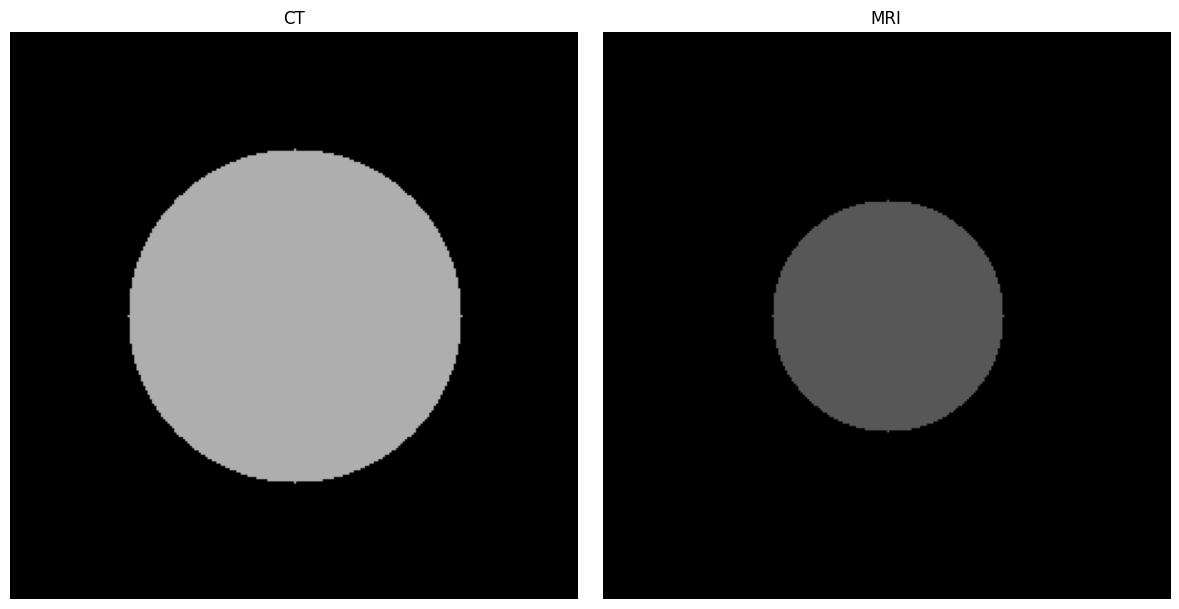

In [12]:
ct = load_gray("data/ct.png")
mri = load_gray("data/mri.png")
if mri.shape != ct.shape:
    mri = cv2.resize(mri, (ct.shape[1], ct.shape[0]), interpolation=cv2.INTER_LINEAR)

print(f"CT: {ct.shape}, range {ct.min()}-{ct.max()}")
print(f"MRI: {mri.shape}, range {mri.min()}-{mri.max()}")
show([ct, mri], ["CT", "MRI"], figsize=(12, 6), save="01_inputs.png")

#### **2. histogram equalization**
each modality is equalized independently so both use their full dynamic range before being blended.

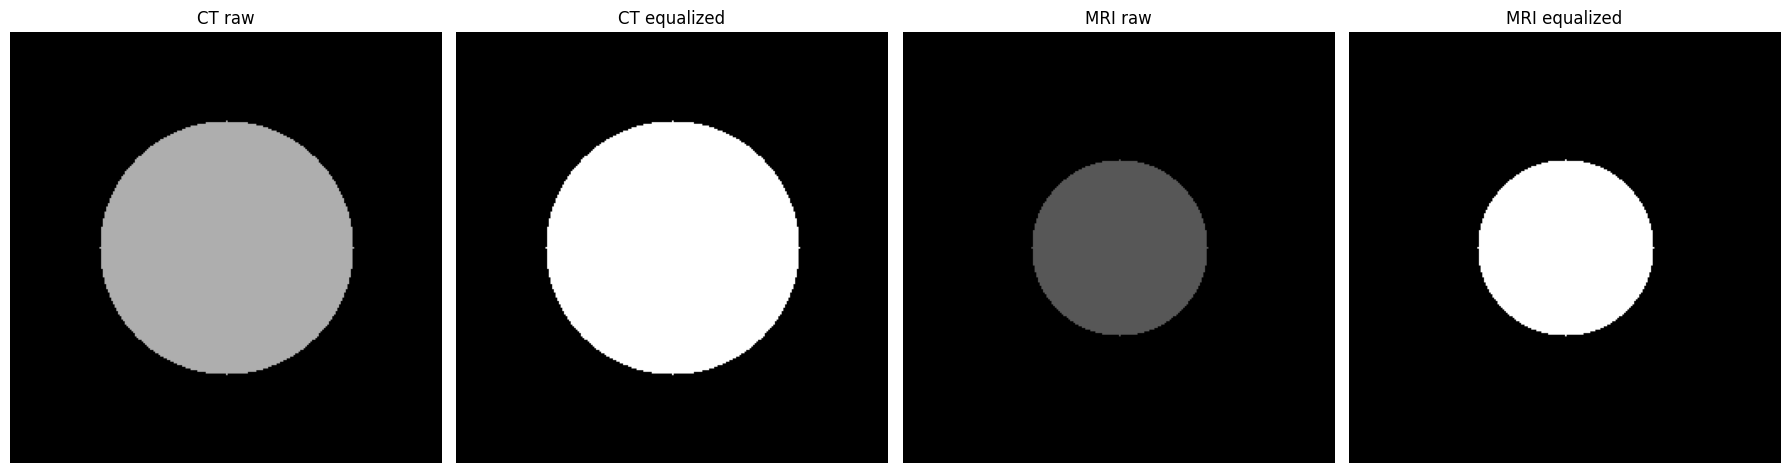

In [13]:
ct_eq = cv2.equalizeHist(ct)
mri_eq = cv2.equalizeHist(mri)
cv2.imwrite("output/02_ct_eq.png", ct_eq)
cv2.imwrite("output/02_mri_eq.png", mri_eq)
show([ct, ct_eq, mri, mri_eq], ["CT raw", "CT equalized", "MRI raw", "MRI equalized"], figsize=(18, 5), save="02_equalized.png")

#### **3. color mapping and overlay**
CT → `COLORMAP_BONE` (keeps the structural look, bright edges), MRI → `COLORMAP_JET` (soft-tissue variations become colour differences). a plain 50/50 overlay is shown first as a baseline.

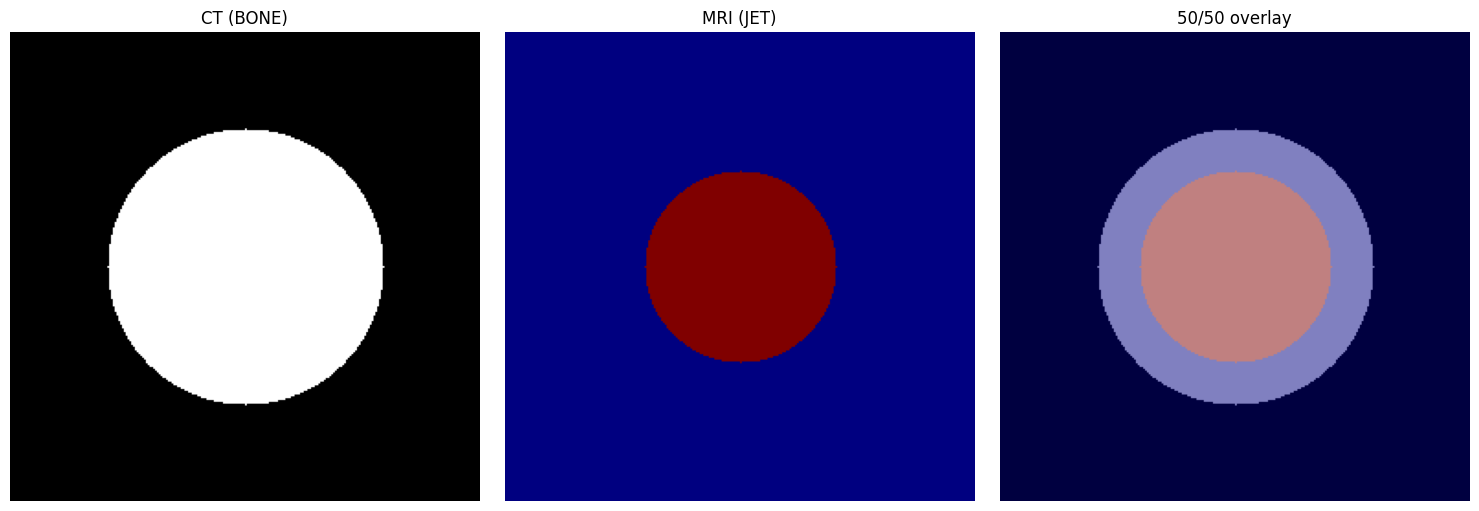

In [14]:
ct_color = cv2.applyColorMap(ct_eq, cv2.COLORMAP_BONE)
mri_color = cv2.applyColorMap(mri_eq, cv2.COLORMAP_JET)
overlay = cv2.addWeighted(ct_color, 0.5, mri_color, 0.5, 0)
cv2.imwrite("output/03_ct_bone.png", ct_color)
cv2.imwrite("output/03_mri_jet.png", mri_color)
cv2.imwrite("output/03_overlay_50_50.png", overlay)
show([ct_color, mri_color, overlay], ["CT (BONE)", "MRI (JET)", "50/50 overlay"], save="03_color_overlay.png")

#### **4. multi-modal weighted fusion**
`fused = α·CT + β·MRI + γ` via `cv2.addWeighted`. the CT gets the **heavier** weight (keeps sharp anatomical edges) and the MRI the **lighter** weight (adds soft-tissue colour without washing out the edges). a few α values are compared.

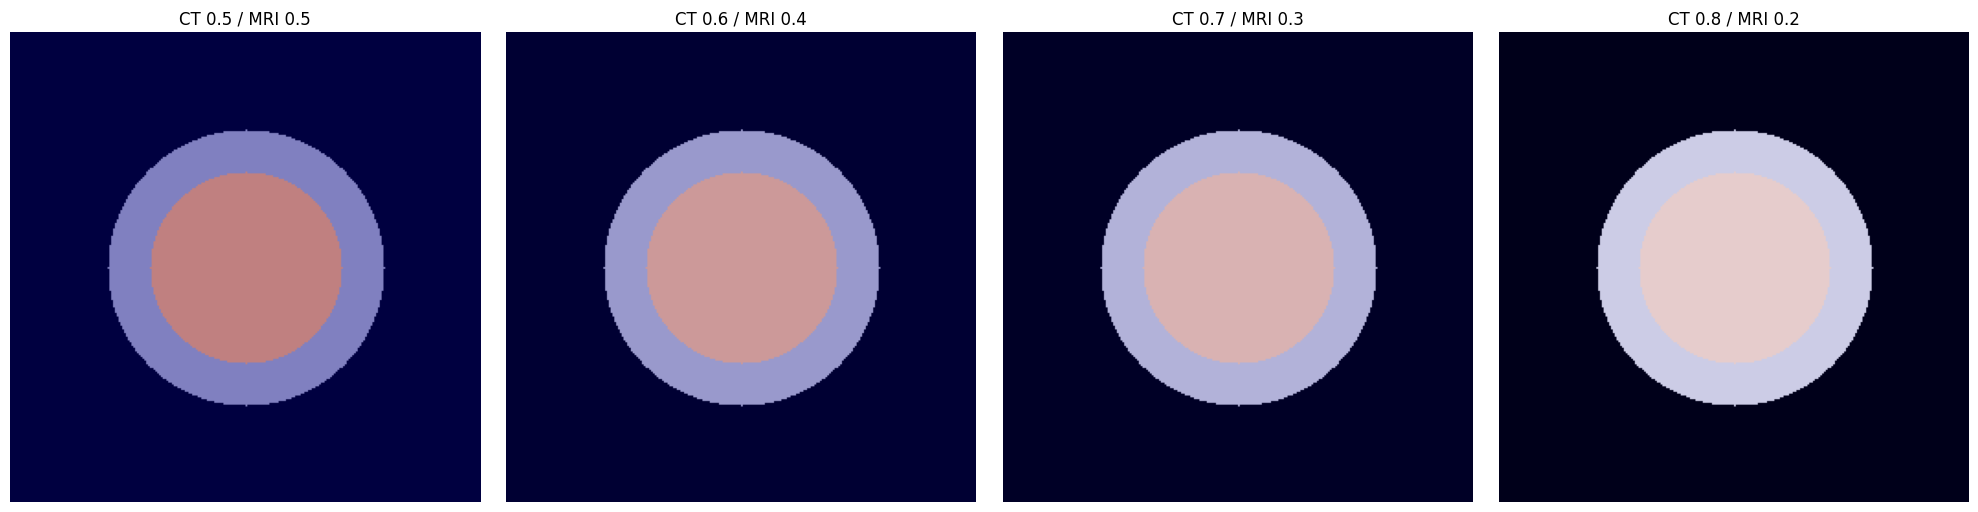

In [15]:
alphas = [0.5, 0.6, 0.7, 0.8]
fusions = [cv2.addWeighted(ct_color, a, mri_color, 1 - a, 0) for a in alphas]
show(fusions, [f"CT {a:.1f} / MRI {1 - a:.1f}" for a in alphas], figsize=(20, 5), save="04_alpha_sweep.png")

ALPHA, BETA = 0.7, 0.3
fused = cv2.addWeighted(ct_color, ALPHA, mri_color, BETA, 0)
_ = cv2.imwrite("output/04_fused.png", fused)

**chosen weights: α = 0.7 (CT), β = 0.3 (MRI)**
- **the inputs:** the CT circle is larger than the MRI circle, so the fused image shows two rings: an outer ring where only the CT has tissue and an inner disc where both overlap.
- **at 0.5 / 0.5:** the JET colours of the MRI dominate. The background turns a noticeable navy blue, and the CT ring is a dull purple with a weak outline.
- **at 0.8 / 0.2:** the MRI almost disappears; the inner disc is barely tinted.
- **at 0.7 / 0.3 (chosen):** the CT outline stays bright and sharp, and the MRI region is still clearly visible as a warm pink tint inside it. This is the balance the task asks for: CT edges first, MRI information on top.

#### **5. logarithmic and power-law transformations**
the fused matrix is passed through log (lifts anything that got crushed towards black) and then gamma (pulls highlights back down so nothing is blown out). the % of pixels at exactly 0 and 255 is checked before and after.

fused                  at 0: 48.70%   at 255:  0.00%   mean:   60.7   distinct colours: 3
fused + log            at 0: 48.70%   at 255:  8.98%   mean:  109.1   distinct colours: 3
fused + log + gamma    at 0: 48.70%   at 255:  8.98%   mean:  103.7   distinct colours: 3


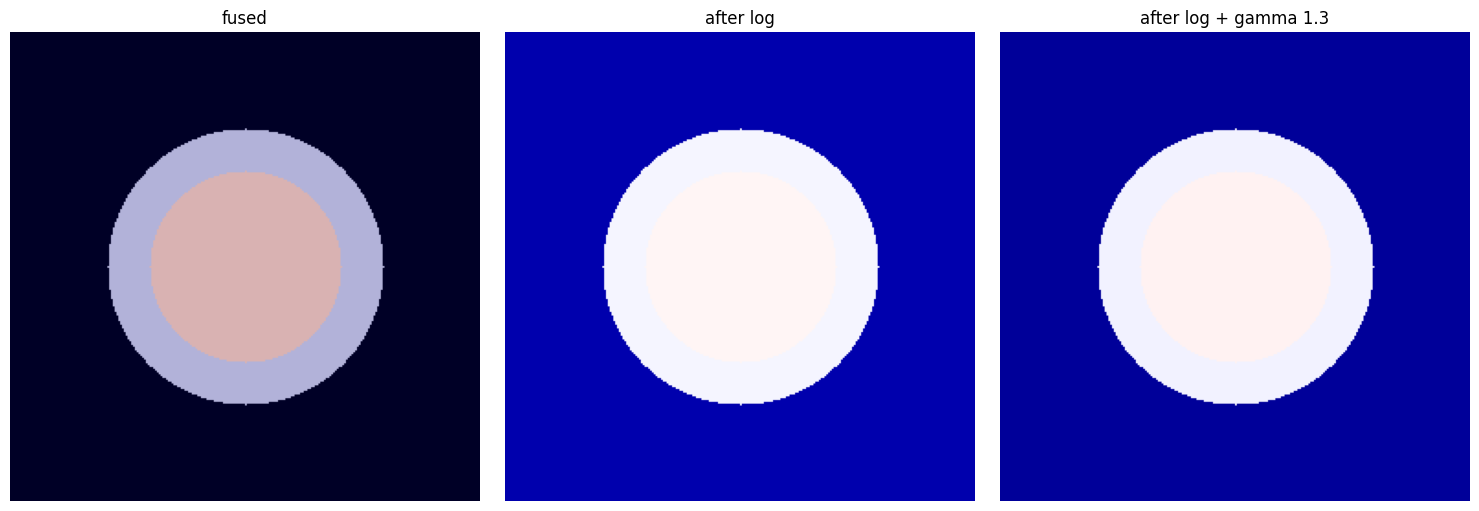

In [16]:
fused_log = log_transform(fused)
fused_final = gamma_transform(fused_log, 1.3)
cv2.imwrite("output/05_fused_log.png", fused_log)
cv2.imwrite("output/05_fused_final.png", fused_final)

for name, im in [("fused", fused), ("fused + log", fused_log), ("fused + log + gamma", fused_final)]:
    b, w = clipped(im)
    levels = len(np.unique(im.reshape(-1, 3), axis=0))
    print(f"{name:22s} at 0: {b:5.2f}%   at 255: {w:5.2f}%   mean: {im.mean():6.1f}   distinct colours: {levels}")

show([fused, fused_log, fused_final], ["fused", "after log", "after log + gamma 1.3"], save="05_log_gamma.png")

**observation:** the synthetic pair is extreme, because the fused image contains only **3 distinct colours** (background, CT-only ring and overlap disc).
- **log:** raises the mean from 60.7 to 109.1. The brightest colour (the overlap disc) is mapped to 255 by definition, so **8.98%** of the channel values now sit at 255.
- **is anything lost?** No. There are still **3 distinct colours** before and after, so the log step only rescaled the colours and nothing actually blew out.
- **the 48.7% of values at 0:** these are background channels that were already 0 in both inputs. log(1 + 0) = 0, so the transforms can't (and shouldn't) change them. This is empty space, not crushed data.
- **gamma 1.3:** pulls the mean back down to 103.7.

the real-CT bonus below gives a more meaningful test of this step.

#### **6. comparative analysis**
standalone CT, standalone MRI and the fused output side-by-side, plus numbers to back up the visual comparison.
- **entropy** - how much intensity information the image carries
- **std dev** - global contrast
- **edge strength** - mean Sobel gradient magnitude (how sharp the boundaries are)

image               entropy     std   edges
CT (equalized)        0.841   113.1    15.0
MRI (equalized)       0.556    85.7    10.4
fused (final)         1.110   100.9    13.4


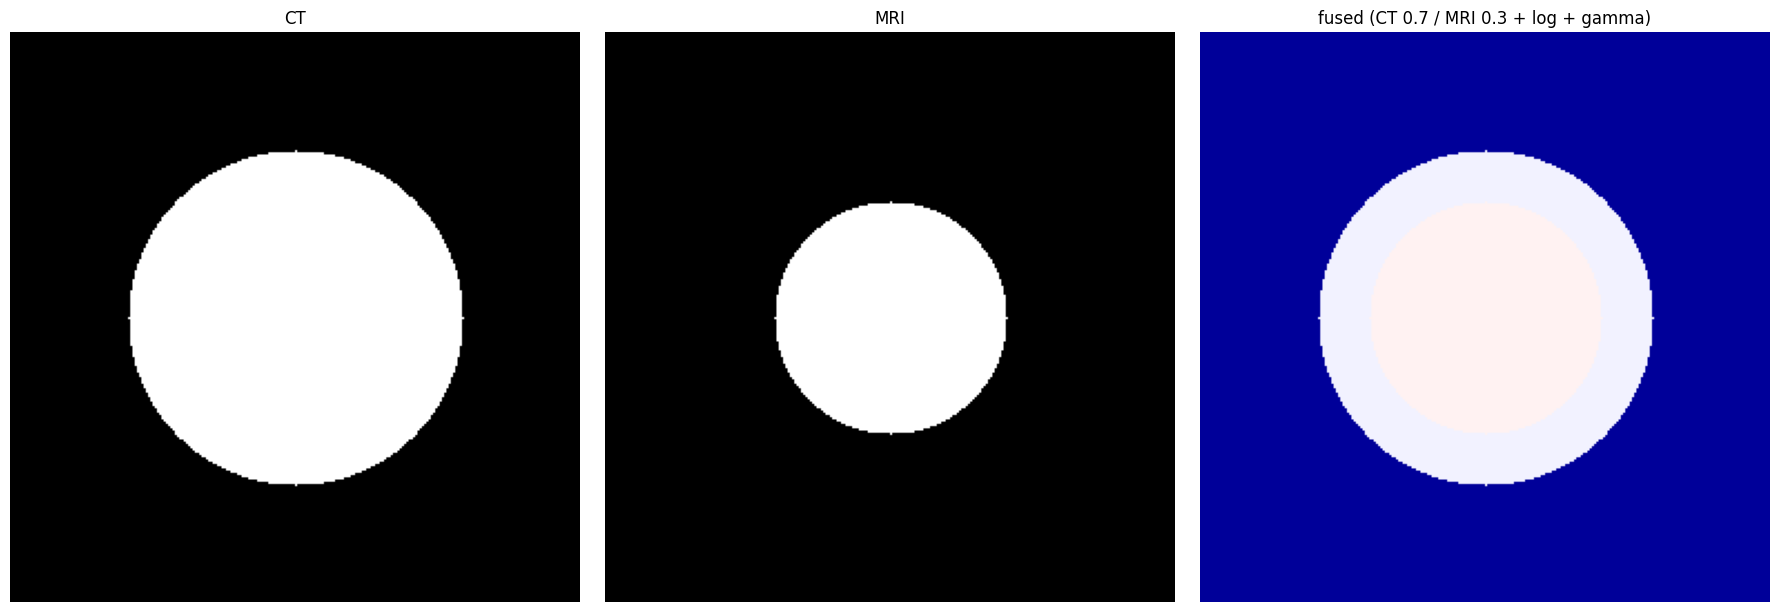

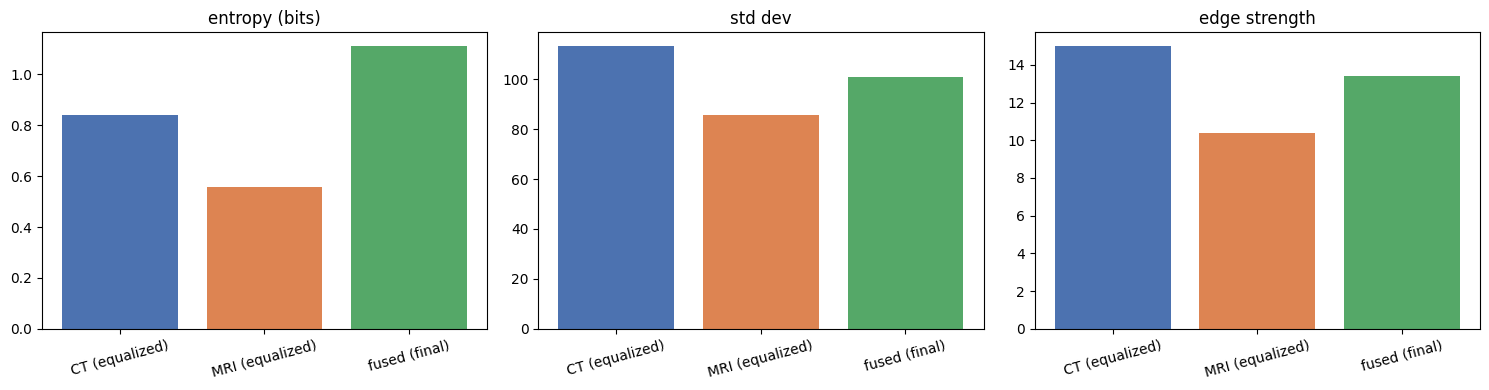

In [17]:
def edge_strength(gray):
    gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0)
    gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1)
    return float(np.hypot(gx, gy).mean())

final_gray = cv2.cvtColor(fused_final, cv2.COLOR_BGR2GRAY)
rows = [("CT (equalized)", ct_eq), ("MRI (equalized)", mri_eq), ("fused (final)", final_gray)]

print(f"{'image':18s} {'entropy':>8s} {'std':>7s} {'edges':>7s}")
for name, im in rows:
    print(f"{name:18s} {entropy(im):8.3f} {im.std():7.1f} {edge_strength(im):7.1f}")

show([ct_eq, mri_eq, fused_final], ["CT", "MRI", "fused (CT 0.7 / MRI 0.3 + log + gamma)"], figsize=(18, 6), save="06_comparison.png")

# bar chart of the metrics
names = [r[0] for r in rows]
metrics = {
    "entropy (bits)": [entropy(im) for _, im in rows],
    "std dev": [im.std() for _, im in rows],
    "edge strength": [edge_strength(im) for _, im in rows],
}
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (title, vals) in zip(axes, metrics.items()):
    ax.bar(names, vals, color=["#4c72b0", "#dd8452", "#55a868"])
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.savefig("output/06_metrics_chart.png", dpi=120)
plt.show()

**conclusion (synthetic pair):**
- **entropy:** 0.84 bits for the CT and 0.56 bits for the MRI, rising to **1.11 bits** for the fused image. The fused view carries more intensity information than either scan alone, because it contains both circles.
- **edge strength:** 13.4, which keeps about **89%** of the CT's 15.0 and is well above the MRI's 10.4. The heavier CT weight preserved the CT boundaries.
- **visually:** the CT outline (structure) and the MRI region (tissue) appear together in one image.

these numbers are small because the inputs are flat circles; the bonus section below shows the same behaviour on real anatomy.

---
## **bonus - the same fusion on a real CT slice**

**why this section exists:** every matched CT/MRI pair in this dataset (`synthetic_slices/`) is simulated. each slice is just a flat two-tone circle, so the main results above prove the pipeline works but can't show anatomy.

the same dataset also has a `DICOM TO PNG/` folder with **50 real chest CT slices, but no MRI**. to show the fusion on real anatomy, slice `0049` is used as the CT and an **MRI-style image is simulated from that same slice**. because it's built from the same slice, the two line up perfectly.

how the MRI-style image is made:
- **soft tissue bright, bone dark.** intensity follows a bell curve centred on the CT soft-tissue level (~150): heart muscle and soft tissue come out bright, dense bone and contrast-filled vessels come out dark (the opposite of CT), and air stays black.
- **lower resolution.** a gaussian blur, because MRI is usually less sharp than CT.
- **uneven brightness.** a smooth left-to-right gain change, the kind of brightness drift MRI scanners typically show.
- **noise.** a little random grain.

soft-tissue level used: 149


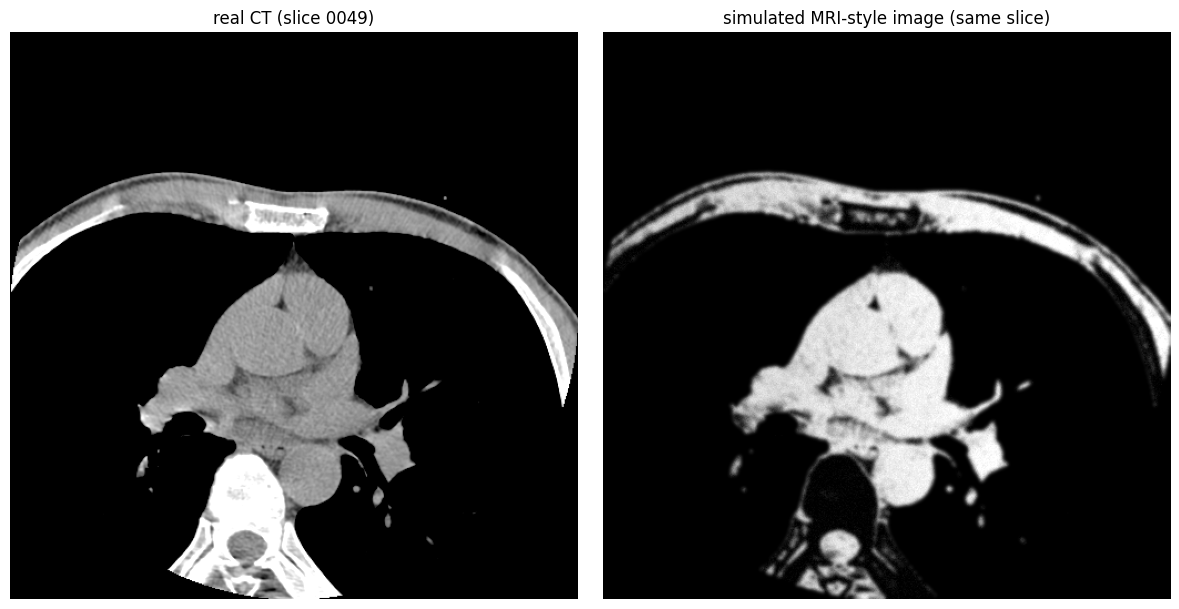

In [18]:
ct_r = load_gray("data/ct_real.png")
body = ct_r > 20

SOFT_LEVEL = float(np.median(ct_r[(ct_r > 30) & (ct_r < 230)]))  # typical soft-tissue gray level in this CT
f = ct_r.astype(np.float64)
mri_sim = 255.0 * np.exp(-((f - SOFT_LEVEL) / 45.0) ** 2) * body       # soft tissue bright, bone / air dark
mri_sim = cv2.GaussianBlur(mri_sim, (0, 0), 1.5)                        # lower resolution
h, w = ct_r.shape
mri_sim *= np.linspace(0.8, 1.1, w)[None, :]                            # scanner brightness drift
mri_sim += np.random.default_rng(7).normal(0, 6, mri_sim.shape) * body  # noise
mri_sim = np.clip(mri_sim, 0, 255).astype(np.uint8)
cv2.imwrite("output/bonus_01_mri_simulated.png", mri_sim)

print(f"soft-tissue level used: {SOFT_LEVEL:.0f}")
show([ct_r, mri_sim], ["real CT (slice 0049)", "simulated MRI-style image (same slice)"], figsize=(12, 6), save="bonus_01_inputs.png")

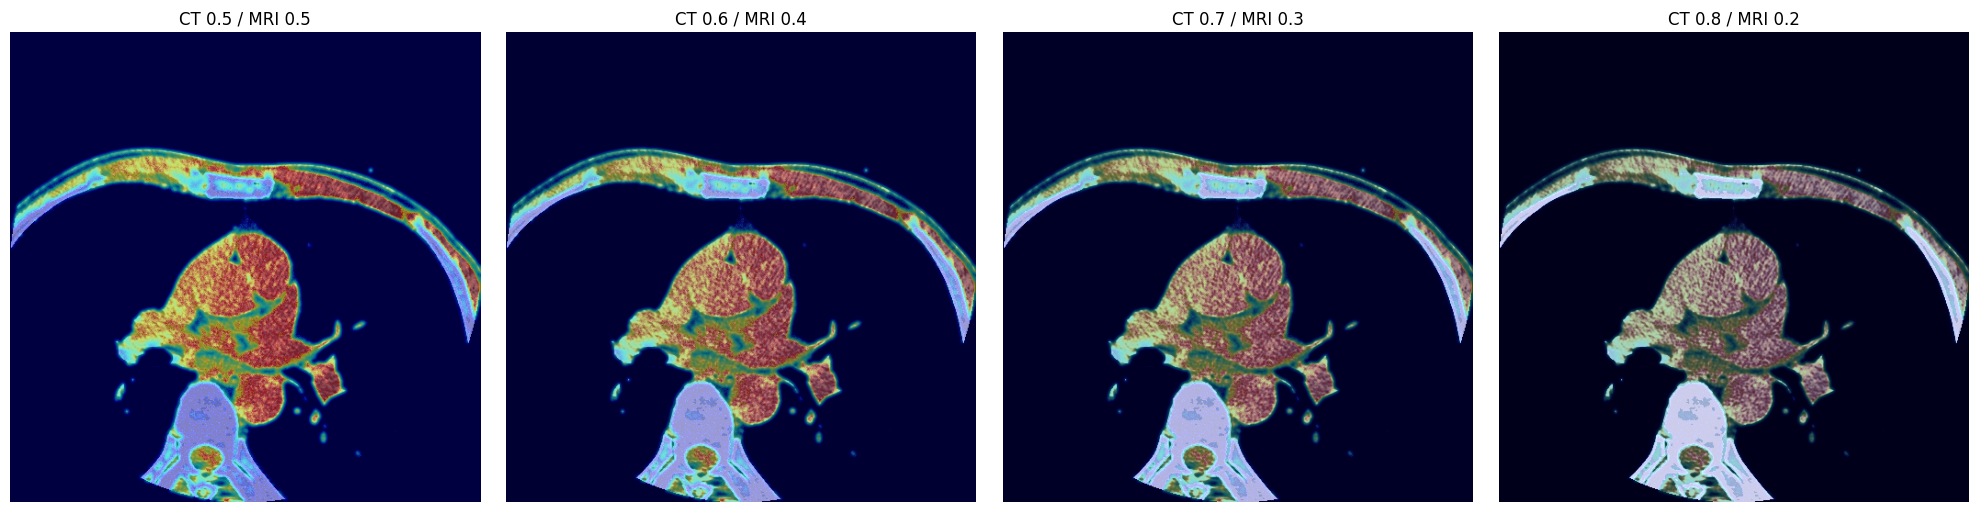

fused                  at 0: 51.13%   at 255:  0.44%   mean:   39.1   distinct colours: 9037
fused + log            at 0: 51.13%   at 255:  0.44%   mean:   93.0   distinct colours: 5892
fused + log + gamma    at 0: 51.13%   at 255:  0.44%   mean:   85.5   distinct colours: 5892


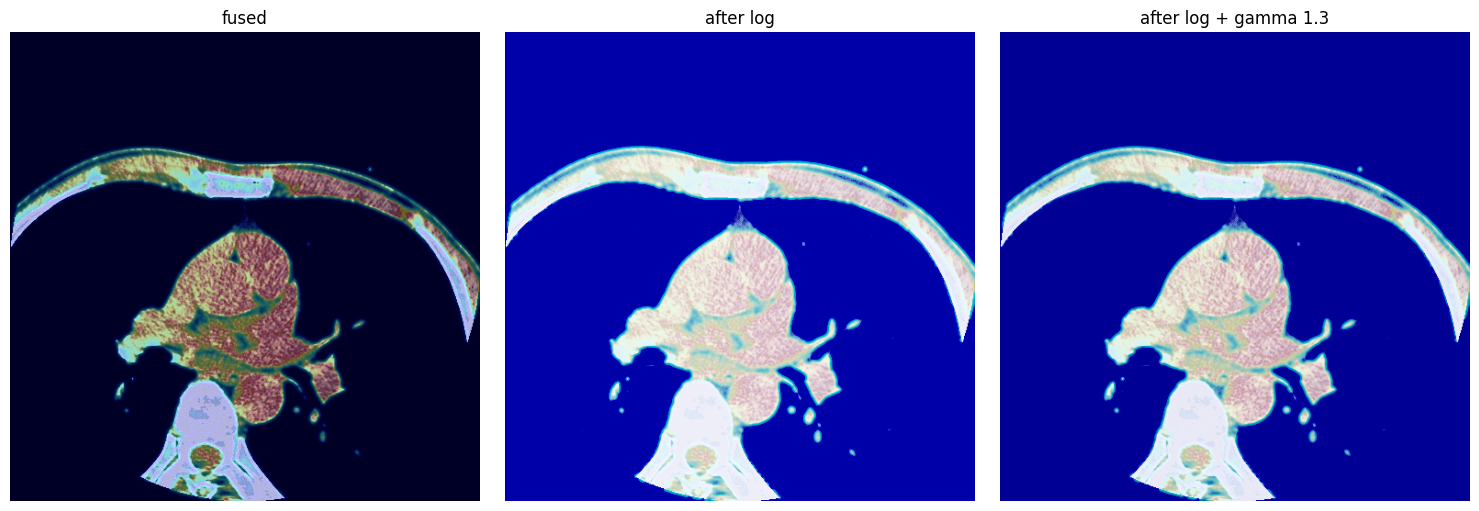

In [19]:
# exactly the same steps as the main pipeline
ct_r_eq = cv2.equalizeHist(ct_r)
mri_sim_eq = cv2.equalizeHist(mri_sim)
ct_r_col = cv2.applyColorMap(ct_r_eq, cv2.COLORMAP_BONE)
mri_sim_col = cv2.applyColorMap(mri_sim_eq, cv2.COLORMAP_JET)

fusions_r = [cv2.addWeighted(ct_r_col, a, mri_sim_col, 1 - a, 0) for a in alphas]
show(fusions_r, [f"CT {a:.1f} / MRI {1 - a:.1f}" for a in alphas], figsize=(20, 5), save="bonus_02_alpha_sweep.png")

fused_r = cv2.addWeighted(ct_r_col, ALPHA, mri_sim_col, BETA, 0)
fused_r_log = log_transform(fused_r)
fused_r_final = gamma_transform(fused_r_log, 1.3)
cv2.imwrite("output/bonus_03_fused_final.png", fused_r_final)

for name, im in [("fused", fused_r), ("fused + log", fused_r_log), ("fused + log + gamma", fused_r_final)]:
    b, w_ = clipped(im)
    levels = len(np.unique(im.reshape(-1, 3), axis=0))
    print(f"{name:22s} at 0: {b:5.2f}%   at 255: {w_:5.2f}%   mean: {im.mean():6.1f}   distinct colours: {levels}")

show([fused_r, fused_r_log, fused_r_final], ["fused", "after log", "after log + gamma 1.3"], save="bonus_03_log_gamma.png")

**observation (real CT):**
- **alpha sweep:** the same pattern as the synthetic pair.
  - at 0.5 / 0.5 the JET red/yellow of the simulated MRI floods the heart and hides the CT texture
  - at 0.7 / 0.3 the CT's bone (sternum, ribs, spine) stays white and sharp, while the heart and vessels keep a red tint from the MRI
- **log:** raises the mean from 39.1 to 93.0, revealing the dark soft tissue around the heart and the chest wall.
- **pure white stays at 0.44%, before and after:** log and gamma did not blow out anything new.
- **the 51% of values at 0:** empty air outside the body, which stays at 0 as expected.
- **the trade-off:** the number of distinct colours falls from **9,037 to 5,892**. The log curve squeezes the bright end together, so some very close bright shades merge. Gamma 1.3 afterwards loses nothing more (still 5,892) and brings the mean back down to 85.5, restoring some contrast in the heart.

image                 entropy     std   edges
CT (equalized)          2.146    66.2    40.3
MRI-sim (equalized)     2.602    66.2    29.2
fused (final)           2.546    80.3    29.2


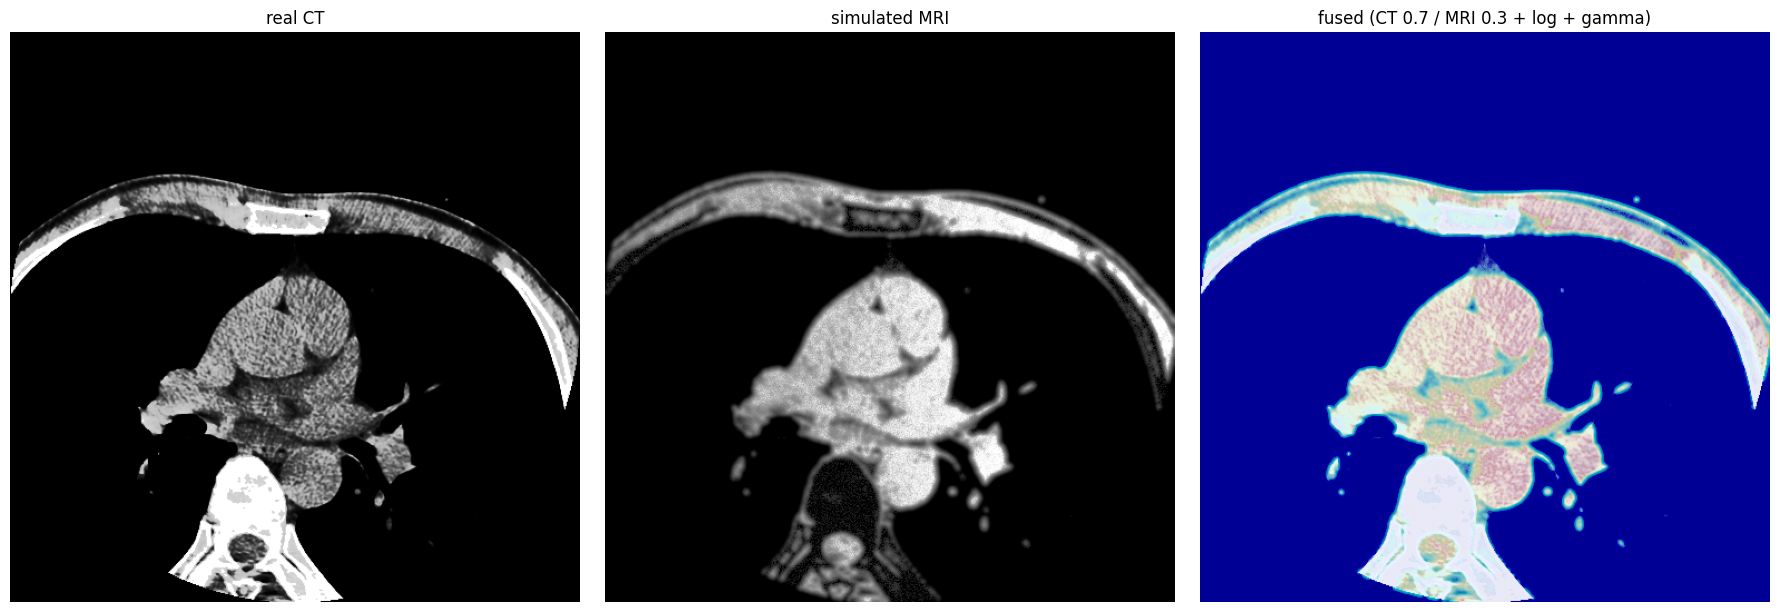

In [20]:
final_r_gray = cv2.cvtColor(fused_r_final, cv2.COLOR_BGR2GRAY)
rows_r = [("CT (equalized)", ct_r_eq), ("MRI-sim (equalized)", mri_sim_eq), ("fused (final)", final_r_gray)]

print(f"{'image':20s} {'entropy':>8s} {'std':>7s} {'edges':>7s}")
for name, im in rows_r:
    print(f"{name:20s} {entropy(im):8.3f} {im.std():7.1f} {edge_strength(im):7.1f}")

show([ct_r_eq, mri_sim_eq, fused_r_final], ["real CT", "simulated MRI", "fused (CT 0.7 / MRI 0.3 + log + gamma)"], figsize=(18, 6), save="bonus_04_comparison.png")

**observation (real CT):**
- **contrast:** the fused image has the highest contrast of the three (std dev **80.3**, against 66.2 for each input).
- **entropy:** 2.55 bits, close to the MRI-style image (2.60) and well above the CT (2.15). It carries the extra soft-tissue information.
- **edge strength:** falls from the CT's **40.3** to **29.2**. Part of this is how it's measured: the colour image is converted back to gray, and the blurred MRI layer softens the gradients.
- **visually:** the bone boundaries are still clearly the sharpest structures in the fused image, and the soft-tissue shading of the heart chambers and vessels comes from the MRI-style layer.

**overall:** with CT weighted 0.7 and MRI 0.3, the fused view keeps the CT's anatomy readable while adding a soft-tissue colour layer, which is the goal of the task. (reminder: the MRI in this section is simulated, not a real scan.)